# File C : MS-GARCH

Selected sections below contain "Long Run Time" warning and are commented out. The section following it loads pre-saved so the notebook runs smoothly

In [5]:
# I have to change the directories 
# Users/shah/CODE_BOOK_4/code_document/THESIS/ModellingAndForecastingVolatility/.venv/bin/active

In [8]:
# import sys
# sys.path.insert(0, "/Users/shah/CODE_BOOK_4/THESIS_WORKING/THESIS")

# sys.modules.pop("src", None)

In [10]:
import sys, os
sys.path.insert(0, os.getcwd())

In [11]:
import pandas as pd
import numpy as np
from math import sqrt, pi, exp
from arch import arch_model
import yfinance as yf 
from scipy.optimize import minimize
import warnings
from arch.__future__ import reindexing
from arch.utility.exceptions import ConvergenceWarning
from src.msGarch import msGARCH
from src.msGarch import msGARCHIV
from tqdm import tqdm
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message="y is poorly scaled")
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
from src.metrics import metrics

In [12]:
# # DO NOT RUN UNTIL CHANGES TO DEPENDENCIES 
# pip freeze > requirements.txt

## Functions MS

$$
\omega_i = e^{w_{\text{raw}, i}} > 0
$$


### MS GARCH no IV

\begin{aligned}
h_{t+1}^{(0)} &= \omega_0 + \alpha_0 \left(u_t^2 + \lambda \sigma_J^2 \right) + \beta_0 h_t^{(0)} \\
h_{t+1}^{(1)} &= \omega_1 + \left(\alpha_1 + \gamma_1 \mathbf{1}_{\{u_t < 0\}}\right)\left(u_t^2 + \lambda \sigma_J^2 \right) + \beta_1 h_t^{(1)} \\
h_{t+1}^{(2)} &= \omega_2 + \alpha_2 \left(u_t^2 + \lambda \sigma_J^2 \right)
+ \beta_2 \left((1 - d) h_t^{(2)} + d \bar{h}_t \right)
\end{aligned}

The third one is Fi garch style, fractionally integrated or mean-mixing volatility regime


### MS GARCH w IV

\begin{aligned}
h_{t+1}^{(0)} &= \omega_0 + \delta\,\mathrm{IV}_t + \alpha_0 \left(u_t^2 + \lambda \sigma_J^2 \right) + \beta_0 h_t^{(0)} \\
h_{t+1}^{(1)} &= \omega_1 + \delta\,\mathrm{IV}_t + \left(\alpha_1 + \gamma_1 \mathbf{1}_{\{u_t < 0\}}\right)\left(u_t^2 + \lambda \sigma_J^2 \right) + \beta_1 h_t^{(1)} \\
h_{t+1}^{(2)} &= \omega_2 + \delta\,\mathrm{IV}_t + \alpha_2 \left(u_t^2 + \lambda \sigma_J^2 \right)
+ \beta_2 \left((1 - d) h_t^{(2)} + d \bar{h}_t \right)
\end{aligned}




## MS-GARCH Base

### Regime 1: Symmetric GARCH with jumps (baseline)
$$
h_{t+1}^{(0)}=\omega_{0}+\alpha_{0}\left(u_t^{2}+\lambda\sigma_{J}^{2}\right)+\beta_{0}h_t^{(0)}.
$$

### Regime 2: Asymmetric GJR-GARCH with jumps (leverage)
$$
h_{t+1}^{(1)}=\omega_{1}+\left(\alpha_{1}+\gamma_{1}\mathbf{1}_{\{u_t<0\}}\right)\left(u_t^{2}+\lambda\sigma_{J}^{2}\right)+\beta_{1}h_t^{(1)}.
$$

### Regime 3: FIGARCH-style long-memory recursion with jumps
$$
h_{t+1}^{(2)}=\omega_{2}+\alpha_{2}\left(u_t^{2}+\lambda\sigma_{J}^{2}\right)+\beta_{2}\left((1-d)\,h_t^{(2)}+d\,\bar{h}_t\right).
$$


## Data (1 min Run Time)

In [13]:
# Hourly data
d_btc = pd.read_parquet("../data/rawData/btc_underlying_minutely_2025.parquet")



In [14]:
# Options with minutely data 
df = pd.read_parquet("../data/rawData/derivative_data_2025.parquet")

In [15]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("../data/rawData")
YEARS = [2022, 2023, 2024, 2025]

d_btc_raw_by_year = {}
df_raw_by_year = {}

for y in YEARS:
    d_btc_raw_by_year[y] = pd.read_parquet(DATA_DIR / f"btc_underlying_minutely_{y}.parquet")
    df_raw_by_year[y]    = pd.read_parquet(DATA_DIR / f"derivative_data_{y}.parquet")


In [16]:
df_raw_by_year[2022]["date_time"]

0         2023-01-01 22:59:20.379
1         2023-01-01 22:58:47.798
2         2023-01-01 22:57:34.244
3         2023-01-01 22:57:28.589
4         2023-01-01 22:55:21.237
                    ...          
2966410   2021-12-31 23:00:34.439
2966411   2021-12-31 23:00:33.612
2966412   2021-12-31 23:00:33.550
2966413   2021-12-31 23:00:33.057
2966414   2021-12-31 23:00:33.036
Name: date_time, Length: 2966415, dtype: datetime64[ns]

In [17]:

# from src.dataPrep import dataprep

# d_btc_by_year = {}
# df_by_year = {}

# for y in YEARS:
#     d_btc = d_btc_raw_by_year[y]
#     df    = df_raw_by_year[y]

#     prep = dataprep(d_btc=d_btc, df=df)
#     d_btc_by_year[y], df_by_year[y] = prep.run_all()


## Prepare MFIV (Commented to avoid Long Run Time)

In [18]:
from src.interpol import MFIVPipeline

In [19]:
# from src.interpol import MFIVPipeline
# import numpy as np
# import pandas as pd

# q = 0.0
# HOURS = [5, 20, 30, 40]

# X_by_year = {}
# MFIV_by_year = {}

# for y in YEARS:
#     d_btc = d_btc_by_year[y].copy()
#     df    = df_by_year[y]

#     for H in HOURS:
#         T = H / (24.0 * 365.0)
#         d_btc[f"F{H}"] = d_btc["Close"] * np.exp((d_btc["rfr"] - q) * T)

#     idx = d_btc.index.tz_localize("UTC") if d_btc.index.tz is None else d_btc.index.tz_convert("UTC")
#     rt  = d_btc["r"].reindex(idx)

#     pipe = MFIVPipeline(df=df, d_btc=d_btc, q=0.0)
#     pipe.build_surfaces()
#     MFIV_byH = pipe.compute_mfiv_byH(H_LIST=[5])

#     mf = MFIV_byH[5].reindex(idx.tz_convert(None))
#     bsiv = mf["bsIV"].to_numpy()
#     mfiv = mf["MFIV"].to_numpy()

#     X_by_year[y] = pd.DataFrame({"rt": rt.values, "bsIV": bsiv, "MFIV": mfiv}, index=idx)
#     MFIV_by_year[y] = MFIV_byH


In [20]:
# from pathlib import Path

# OUTDIR = Path("../../data/readyData/modelT")
# OUTDIR.mkdir(parents=True, exist_ok=True)

# for y, X in X_by_year.items():
#     X.to_parquet(OUTDIR / f"d_X_{y}.parquet")


## Load Same Data

In [21]:

import pandas as pd
from pathlib import Path

INDIR = Path("../data/readyData")
YEARS = [2022, 2023, 2024, 2025]

X_by_year = {y: pd.read_parquet(INDIR / f"d_X_{y}.parquet") for y in YEARS}


In [22]:

import numpy as np

eps = 1e-12
for y, X in X_by_year.items():
    X_by_year[y][["bsIV","MFIV"]] = np.exp(
        np.log(X[["bsIV","MFIV"]].clip(lower=eps))
          .interpolate(method="time", limit_direction="both")
    )


In [23]:
# Split by quarter
Xq_by_year = {}

for y, X in X_by_year.items():
    Xq_by_year[y] = {
        "q1": X.loc[f"{y}-01-01":f"{y}-03-31 23:59:59"],
        "q2": X.loc[f"{y}-04-01":f"{y}-06-30 23:59:59"],
        "q3": X.loc[f"{y}-07-01":f"{y}-09-30 23:59:59"],
        "q4": X.loc[f"{y}-10-01":f"{y}-12-31 23:59:59"],
    }

# example: Xq_by_year[2025]["q1"]


In [24]:

Xq_by_year[2023]['q2']["rv"] = Xq_by_year[2023]['q2']["rt"]**2

In [25]:
from src.msGarch import msGARCH
from src.msGarch import msGARCHIV

## MS Base (Long Run Time)

In [ ]:
from src.msGarch import msGARCH
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from tqdm import tqdm
import numpy as np

quarters = [(y, q, Xq_by_year[y][q]) for y in YEARS for q in ["q1", "q2", "q3", "q4"]]

rolling_forecasts = {}
rolling_residuals = {}

idx_by_year = {}
f_rollB_by_year = {}
y_pred_by_year = {}
y_true_by_year = {}
regime_by_year = {}

for y, q, Xq in quarters:

    if y not in rolling_forecasts:
        rolling_forecasts[y] = {}
        rolling_residuals[y] = {}
        idx_by_year[y] = {}
        f_rollB_by_year[y] = {}
        y_pred_by_year[y] = {}
        y_true_by_year[y] = {}
        regime_by_year[y] = {}

    ms = msGARCH()
    prev_theta = ms.theta0.copy()

    regimeB, f_rollB, idx = [], [], []
    dt = Xq.index.tz_convert(None).to_pydatetime()
    Xn = Xq.to_numpy(dtype=float)

    for i in tqdm(range(10, len(Xn)), total=len(range(10, len(Xn))), desc=f"{y}_{q}"):

        r_sub = Xn[i-10:i, 0]
        mu = r_sub.mean()
        sigma = r_sub.std() or 1.0
        r_std = (r_sub - mu) / sigma

        res = minimize(
            ms.nll_ms_garch,
            prev_theta,
            args=(r_std, 3),
            method="L-BFGS-B",
            options={"maxiter": 300, "ftol": 1e-5}
        )

        theta_i = prev_theta if (not res.success or not np.isfinite(res.fun)) else res.x
        prev_theta = theta_i

        f_next, reg = ms.forecast_var_k(r_std, theta_i, R=3, k=1)
        f_next = f_next * (sigma**2)

        regimeB.append(reg[-1])
        f_rollB.append(f_next[-1])
        idx.append(i)

    f_rollB = np.array(f_rollB)
    idx = np.array(idx)

    x_plotB = dt[idx]
    y_true = Xn[idx, 0]**2

    idx_by_year[y][q] = idx
    f_rollB_by_year[y][q] = f_rollB
    rolling_forecasts[y][q] = f_rollB
    rolling_residuals[y][q] = y_true - f_rollB
    y_pred_by_year[y][q] = f_rollB
    y_true_by_year[y][q] = y_true
    regime_by_year[y][q] = regimeB

    plt.figure(figsize=(6, 3))
    plt.plot(x_plotB, y_true, label="Realized Var", linewidth=1)
    plt.plot(x_plotB, f_rollB, label="Rolling 1-Step Forecast", linewidth=1)
    plt.plot(x_plotB, np.array(regimeB)[:, 1] * 0.9 * plt.ylim()[1], color="black", alpha=0.6)
    plt.title(f"{y}_{q}")
    plt.tight_layout()
    plt.show()

In [27]:
[k for k in globals() if not k.startswith("__") and not k.startswith("_")]

['In',
 'Out',
 'get_ipython',
 'exit',
 'quit',
 'open',
 'sys',
 'pd',
 'np',
 'sqrt',
 'pi',
 'exp',
 'arch_model',
 'yf',
 'minimize',
 'warnings',
 'reindexing',
 'ConvergenceWarning',
 'msGARCH',
 'msGARCHIV',
 'tqdm',
 'metrics',
 'os',
 'd_btc',
 'df',
 'Path',
 'DATA_DIR',
 'YEARS',
 'd_btc_raw_by_year',
 'df_raw_by_year',
 'y',
 'MFIVPipeline',
 'INDIR',
 'X_by_year',
 'eps',
 'X',
 'Xq_by_year',
 'plt',
 'quarters',
 'rolling_forecasts',
 'rolling_residuals',
 'idx_by_year',
 'f_rollB_by_year',
 'y_pred_by_year',
 'y_true_by_year',
 'regime_by_year',
 'q',
 'Xq',
 'ms',
 'prev_theta',
 'regimeB',
 'f_rollB',
 'idx',
 'dt',
 'Xn',
 'i',
 'r_sub',
 'mu',
 'sigma',
 'r_std',
 'res',
 'theta_i',
 'f_next',
 'reg',
 'x_plotB',
 'y_true']

In [28]:
# # SAVE BASE
# import pickle
# pickle.dump({k:v for k,v in globals().items()
#              if k.startswith(("idx_","f_rollB_","y_true_","y_pred_","regime_","rolling_forecasts","rolling_residuals"))},
#             open("outputs/ms_garch_base_outputs.pkl","wb"))


## Load MS-GARCH output

In [35]:

#LOAD BASE 
import pickle
globals().update(pickle.load(open("../outputs/ms_garch_base_outputs.pkl","rb")))


FileNotFoundError: [Errno 2] No such file or directory: '../outputs/ms_garch_base_outputs.pkl'

In [34]:

#LOAD BASE 
import pickle
globals().update(pickle.load(open("outputs/ms_garch_gatedIV_outputs.pkl","rb")))


FileNotFoundError: [Errno 2] No such file or directory: 'outputs/ms_garch_gatedIV_outputs.pkl'

In [ ]:

#LOAD BASE 
import pickle
globals().update(pickle.load(open("outputs/ms_garch_noIV_outputs.pkl","rb")))

In [ ]:

from src.LSTM_lib import LSTMGatedIVCorrection

## Three Models by Quarter

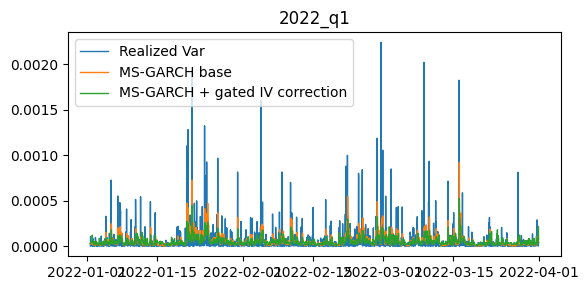

2022_q1
                RMSE       MAE       NLL     QLIKE      Bias
MS_base     0.000156  0.000067 -3.388802 -8.615480 -0.000002
MS_gatedIV  0.000151  0.000062 -3.510812 -8.859502  0.000003


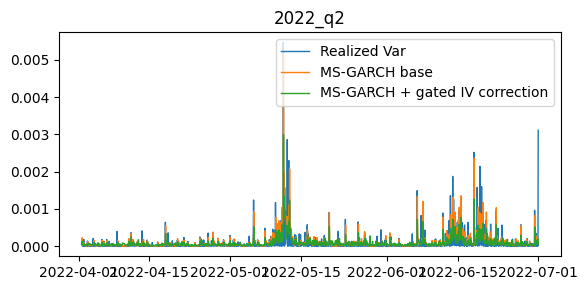

2022_q2
                RMSE       MAE       NLL     QLIKE      Bias
MS_base     0.000254  0.000097 -3.364607 -8.567091 -0.000024
MS_gatedIV  0.000227  0.000084 -3.492109 -8.822094 -0.000005


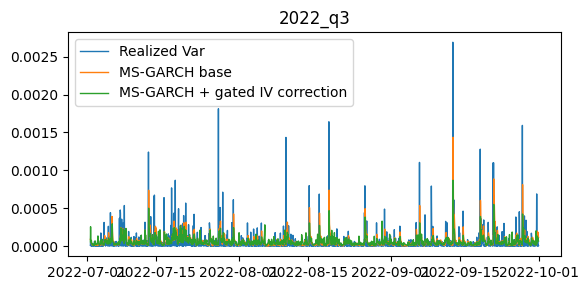

2022_q3
                RMSE       MAE       NLL     QLIKE      Bias
MS_base     0.000154  0.000067 -3.394161 -8.626200 -0.000017
MS_gatedIV  0.000143  0.000064 -3.521129 -8.880136 -0.000014


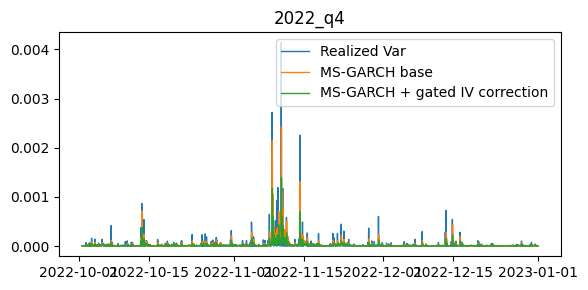

2022_q4
                RMSE       MAE       NLL     QLIKE      Bias
MS_base     0.000154  0.000035 -1.936874 -5.711625 -0.000001
MS_gatedIV  0.000143  0.000030 -3.906712 -9.651302  0.000007


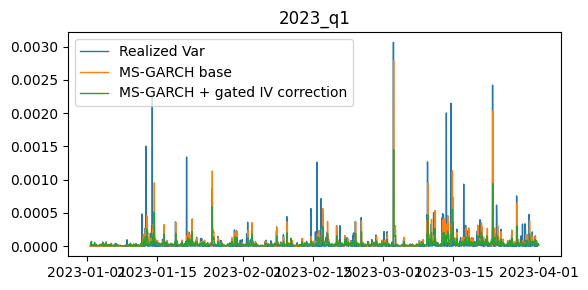

2023_q1
                RMSE       MAE       NLL     QLIKE      Bias
MS_base     0.000176  0.000056 -3.441721 -8.721318 -0.000009
MS_gatedIV  0.000153  0.000045 -3.676598 -9.191074  0.000003


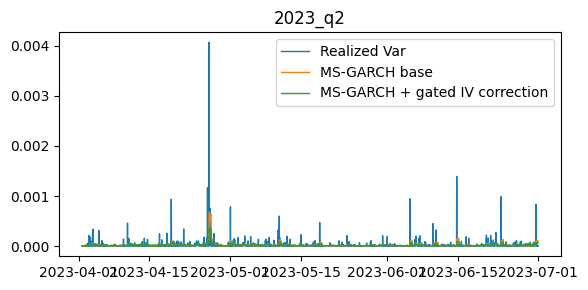

2023_q2
                RMSE       MAE       NLL     QLIKE      Bias
MS_base     0.000117  0.000028 -3.604860 -9.047598  0.000000
MS_gatedIV  0.000113  0.000025 -3.856314 -9.550504  0.000004


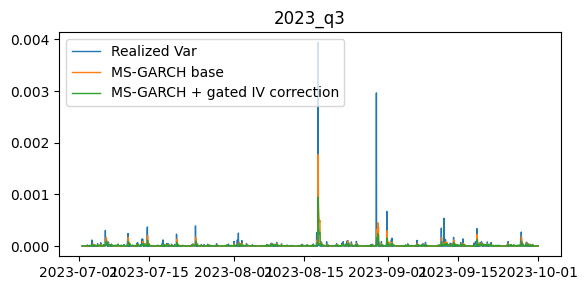

2023_q3
                RMSE       MAE       NLL      QLIKE      Bias
MS_base     0.000121  0.000021 -3.967877  -9.773630 -0.000004
MS_gatedIV  0.000113  0.000017 -4.254060 -10.345996  0.000000


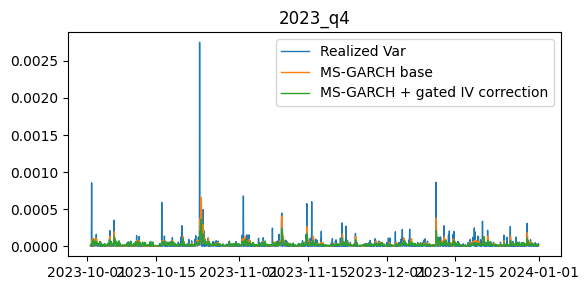

2023_q4
                RMSE       MAE       NLL     QLIKE      Bias
MS_base     0.000085  0.000028 -3.805221 -9.448319 -0.000005
MS_gatedIV  0.000080  0.000025 -3.996698 -9.831272 -0.000002


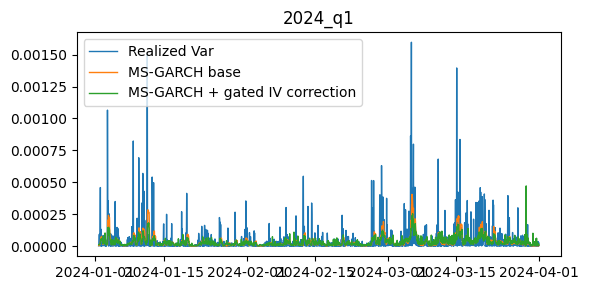

2024_q1
              RMSE       MAE       NLL     QLIKE      Bias
MS_base     0.0001  0.000042 -3.638435 -9.114748  0.000003
MS_gatedIV  0.0001  0.000041 -3.754753 -9.347383  0.000005


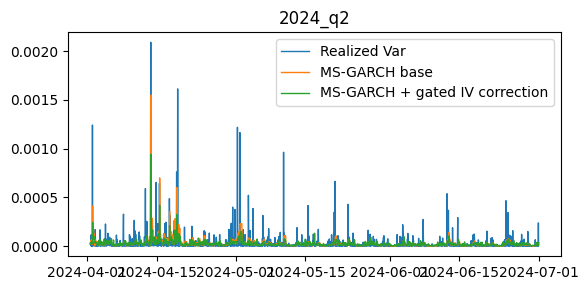

2024_q2
                RMSE       MAE       NLL     QLIKE      Bias
MS_base     0.000099  0.000035 -3.698873 -9.235622  0.000000
MS_gatedIV  0.000095  0.000032 -3.825935 -9.489747  0.000003


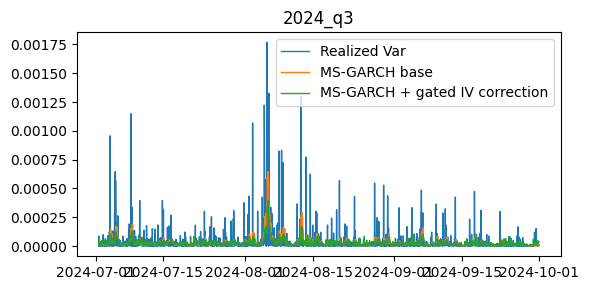

2024_q3
                RMSE       MAE       NLL     QLIKE      Bias
MS_base     0.000111  0.000043 -3.557420 -8.952717  0.000003
MS_gatedIV  0.000109  0.000040 -3.673965 -9.185808  0.000007


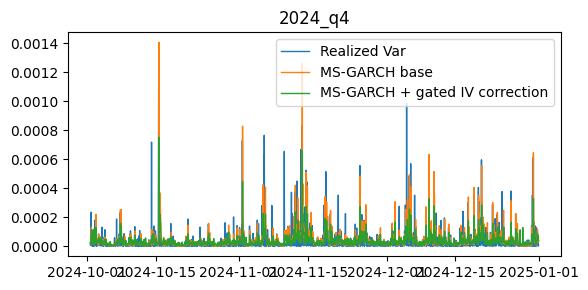

2024_q4
                RMSE       MAE       NLL     QLIKE      Bias
MS_base     0.000104  0.000046 -3.592612 -9.023101 -0.000010
MS_gatedIV  0.000087  0.000039 -3.792865 -9.423608 -0.000002


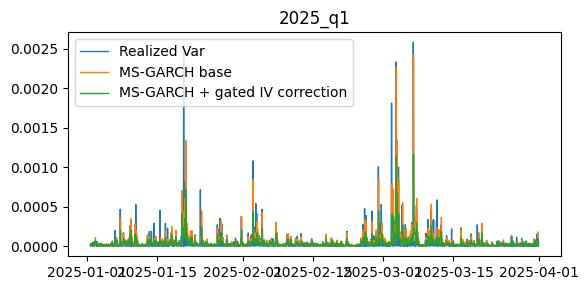

2025_q1
                RMSE       MAE       NLL     QLIKE      Bias
MS_base     0.000160  0.000055 -3.672735 -9.183347 -0.000011
MS_gatedIV  0.000136  0.000044 -3.758616 -9.355109  0.000002


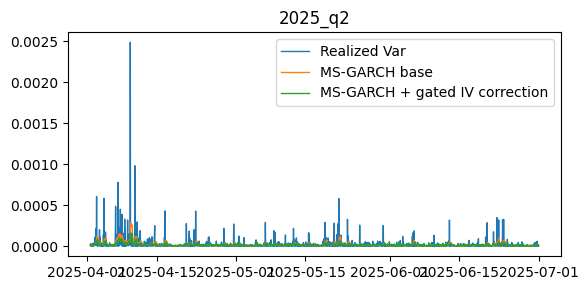

2025_q2
                RMSE       MAE       NLL     QLIKE      Bias
MS_base     0.000077  0.000024 -3.915482 -9.668842  0.000002
MS_gatedIV  0.000076  0.000022 -4.008067 -9.854012  0.000005


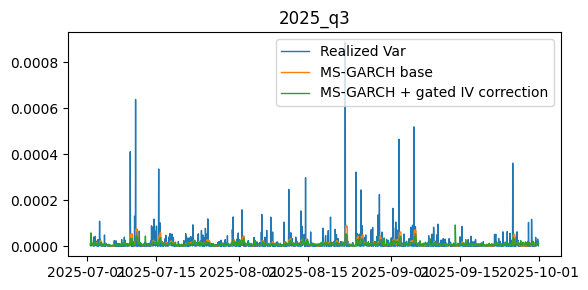

2025_q3
                RMSE       MAE       NLL      QLIKE      Bias
MS_base     0.000038  0.000013 -4.071302  -9.980481  0.000001
MS_gatedIV  0.000038  0.000012 -4.245277 -10.328431  0.000002


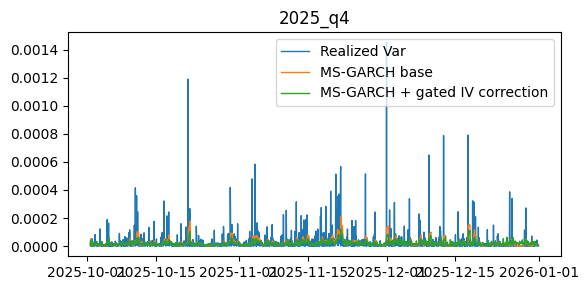

2025_q4
                RMSE       MAE       NLL     QLIKE      Bias
MS_base     0.000074  0.000029 -3.593937 -9.025751  0.000003
MS_gatedIV  0.000072  0.000028 -3.806467 -9.450811  0.000005


In [ ]:
# Requires : idx_by_year[y][q], f_rollB_by_year[y][q]
# MS-GARCH base + LSTM correction (w IV) per quarter
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

quarters = [(y, q, Xq_by_year[y][q]) for y in YEARS for q in ["q1","q2","q3","q4"]]

h_final_byQ = {}
g_hat_byQ   = {}
w_byQ       = {}

tables_gatedIV = {}
rv2_gatedIV_by_year = {}
h_base2_gatedIV_by_year = {}

for y, q, Xq in quarters:

    idx_q    = np.asarray(idx_by_year[y][q], int)
    f_roll_q = np.asarray(f_rollB_by_year[y][q], float)

    t_idx  = Xq.index[idx_q]
    df_use = Xq.loc[t_idx, ["rt","bsIV","MFIV"]].copy()

    h_base_s = pd.Series(np.asarray(f_roll_q, float), index=t_idx)

    mask = df_use.notna().all(axis=1) & np.isfinite(h_base_s.values)
    df_use = df_use.loc[mask]
    h_base = h_base_s.loc[mask].to_numpy(float)

    rv = (df_use["rt"].to_numpy(float) ** 2)

    SEQ_LEN = 5
    feats = df_use[["bsIV","MFIV"]].to_numpy(np.float32)
    X_seq = []
    for i in range(SEQ_LEN, len(df_use)):
        X_seq.append(feats[i-SEQ_LEN:i])
    X_seq = torch.tensor(np.stack(X_seq))

    h_base2 = h_base[SEQ_LEN:]
    H = 5
    dt_years = H / (365.25 * 24.0)
    mfiv_H = np.maximum(df_use["MFIV"].shift(1).to_numpy(float) * dt_years, 1e-12)  # No lookahead

    scale = np.nanmedian(h_base2) / np.nanmedian(mfiv_H[SEQ_LEN:])
    h_iv2 = np.maximum(mfiv_H[SEQ_LEN:] * scale, 1e-12)

    rv2 = rv[SEQ_LEN:]

    g_hat = np.full(len(rv2), np.nan, dtype=float)
    last_w = None

    for t in range(1, len(rv2)):
        lstm_corr = LSTMGatedIVCorrection(hidden_dim=32, lr=1e-3, epochs=30).fit_xy(
            X_seq[:t], rv2[:t], h_base2[:t], h_iv2[:t]
        )
        g_hat[t] = lstm_corr.predict(X_seq[t:t+1], h_base2[t:t+1], h_iv2[t:t+1]).ravel()[0]
        last_w = getattr(lstm_corr, "last_w", None)

    h_base2 = h_base2[1:]
    h_iv2   = h_iv2[1:]
    rv2     = rv2[1:]
    g_hat   = g_hat[1:]
    h_final = h_base2 * np.exp(g_hat)

    if y not in h_final_byQ:
        h_final_byQ[y] = {}
        g_hat_byQ[y] = {}
        w_byQ[y] = {}
        tables_gatedIV[y] = {}
        rv2_gatedIV_by_year[y] = {}
        h_base2_gatedIV_by_year[y] = {}

    h_final_byQ[y][q] = h_final #  h is base forecast variance as numpy array
    g_hat_byQ[y][q]   = g_hat # g is predicted log correction term  |-|-|  g_hat ≈ log(rv / h_base)
    w_byQ[y][q]       = last_w

    x_plot2 = df_use.index[SEQ_LEN:][1:]

    rv2_gatedIV_by_year[y][q]     = rv2
    h_base2_gatedIV_by_year[y][q] = h_base2

    plt.figure(figsize=(6,3))
    plt.plot(x_plot2, rv2,     linewidth=1, label="Realized Var")
    plt.plot(x_plot2, h_base2, linewidth=1, label="MS-GARCH base")
    plt.plot(x_plot2, h_final, linewidth=1, label="MS-GARCH + gated IV correction")
    plt.title(f"{y}_{q}"); plt.legend(); plt.tight_layout(); plt.show()

    results = {}
    results["MS_base"]      = metrics(rv2, h_base2)
    results["MS_gatedIV"]   = metrics(rv2, h_final)

    table = pd.DataFrame(results, index=["RMSE","MAE","NLL","QLIKE","Bias"]).T.round(6)
    tables_gatedIV[y][q] = table
    print(f"{y}_{q}")
    print(table)
    

In [ ]:
# SAVE GATED IV
import pickle

pickle.dump(
    {
        "h_final_byQ": h_final_byQ,
        "g_hat_byQ": g_hat_byQ,
        "w_byQ": w_byQ,
        "tables_gatedIV": tables_gatedIV,
        "rv2_gatedIV_by_year": rv2_gatedIV_by_year,
        "h_base2_gatedIV_by_year": h_base2_gatedIV_by_year,
    },
    open("outputs/ms_garch_gatedIV_outputs.pkl", "wb")
)

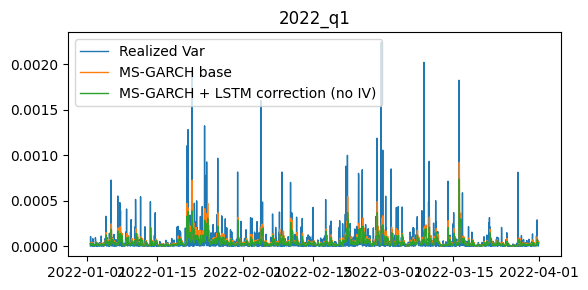

2022_q1
                  RMSE       MAE       NLL     QLIKE      Bias
MS_base       0.000156  0.000067 -3.388802 -8.615480 -0.000002
MS_LSTM_noIV  0.000153  0.000058 -3.193961 -8.225799  0.000012


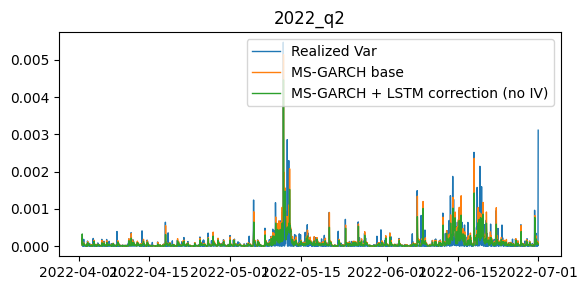

2022_q2
                  RMSE       MAE       NLL     QLIKE      Bias
MS_base       0.000254  0.000097 -3.364607 -8.567091 -0.000024
MS_LSTM_noIV  0.000234  0.000081 -3.193014 -8.223905  0.000001


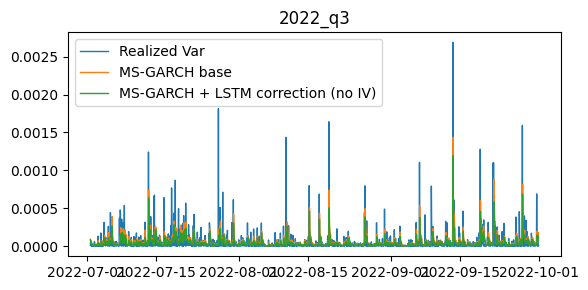

2022_q3
                  RMSE       MAE       NLL    QLIKE      Bias
MS_base       0.000154  0.000067 -3.394161 -8.62620 -0.000017
MS_LSTM_noIV  0.000145  0.000057 -3.231651 -8.30118 -0.000001


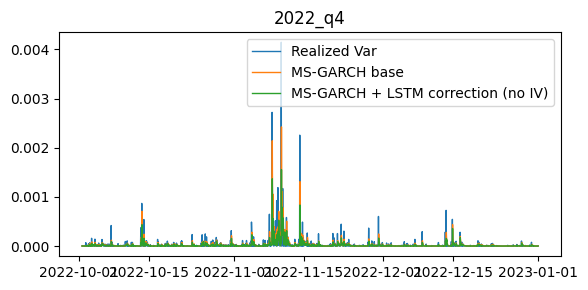

2022_q4
                  RMSE       MAE       NLL     QLIKE      Bias
MS_base       0.000154  0.000035 -1.936874 -5.711625 -0.000001
MS_LSTM_noIV  0.000144  0.000030 -0.733673 -3.305223  0.000007


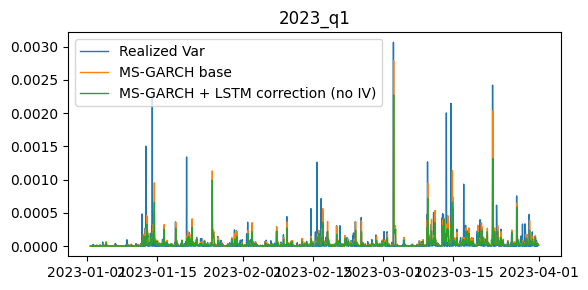

2023_q1
                  RMSE       MAE       NLL     QLIKE      Bias
MS_base       0.000176  0.000056 -3.441721 -8.721318 -0.000009
MS_LSTM_noIV  0.000163  0.000047 -3.165688 -8.169254  0.000002


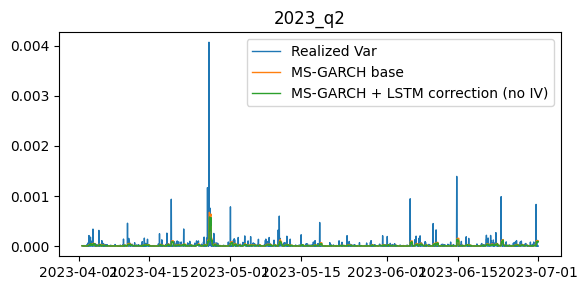

2023_q2
                  RMSE       MAE       NLL     QLIKE      Bias
MS_base       0.000117  0.000028 -3.604860 -9.047598  0.000000
MS_LSTM_noIV  0.000115  0.000025 -3.338175 -8.514228  0.000006


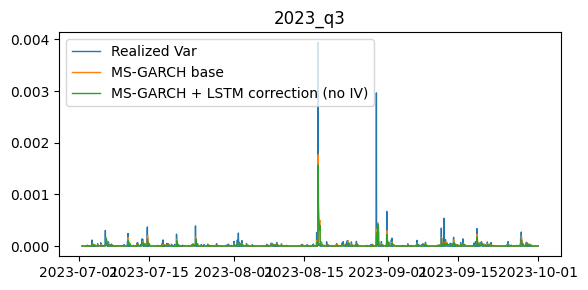

2023_q3
                  RMSE       MAE       NLL     QLIKE      Bias
MS_base       0.000121  0.000021 -3.967877 -9.773630 -0.000004
MS_LSTM_noIV  0.000116  0.000018 -3.610865 -9.059608  0.000000


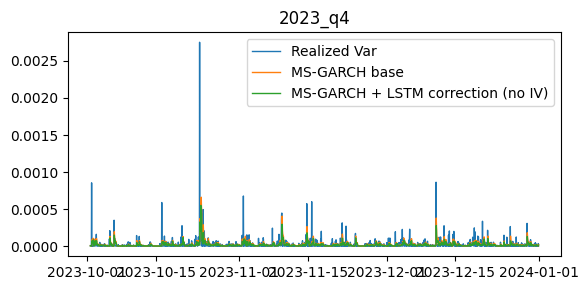

2023_q4
                  RMSE       MAE       NLL     QLIKE      Bias
MS_base       0.000085  0.000028 -3.805221 -9.448319 -0.000005
MS_LSTM_noIV  0.000081  0.000024 -3.615141 -9.068159  0.000002


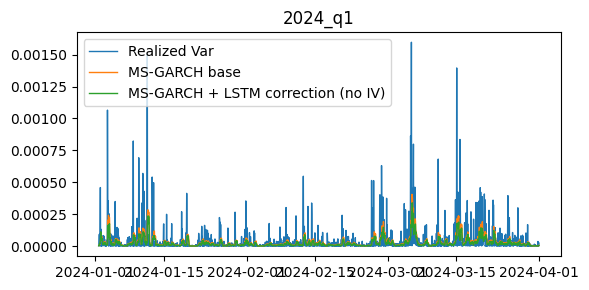

2024_q1
                  RMSE       MAE       NLL     QLIKE      Bias
MS_base       0.000100  0.000042 -3.638435 -9.114748  0.000003
MS_LSTM_noIV  0.000099  0.000038 -3.441714 -8.721306  0.000012


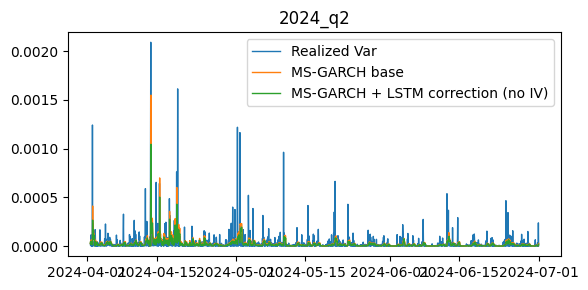

2024_q2
                  RMSE       MAE       NLL     QLIKE      Bias
MS_base       0.000099  0.000035 -3.698873 -9.235622  0.000000
MS_LSTM_noIV  0.000096  0.000031 -3.475548 -8.788972  0.000007


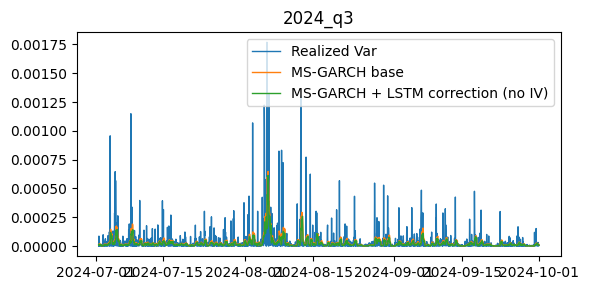

2024_q3
                  RMSE       MAE       NLL     QLIKE      Bias
MS_base       0.000111  0.000043 -3.557420 -8.952717  0.000003
MS_LSTM_noIV  0.000110  0.000039 -3.335265 -8.508407  0.000011


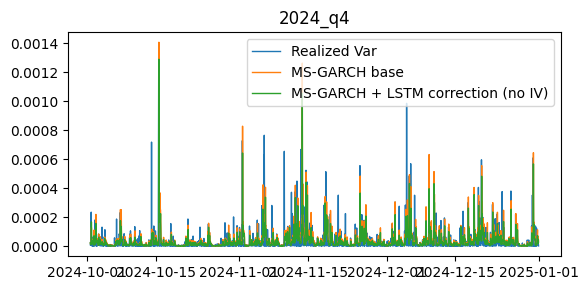

2024_q4
                  RMSE       MAE       NLL     QLIKE     Bias
MS_base       0.000104  0.000046 -3.592612 -9.023101 -0.00001
MS_LSTM_noIV  0.000096  0.000039 -3.409427 -8.656731  0.00000


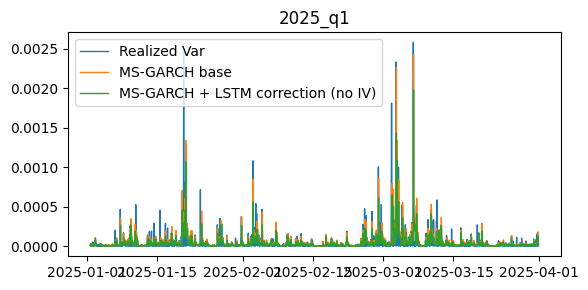

2025_q1
                  RMSE       MAE       NLL     QLIKE      Bias
MS_base       0.000160  0.000055 -3.672735 -9.183347 -0.000011
MS_LSTM_noIV  0.000144  0.000046 -3.486563 -8.811004  0.000002


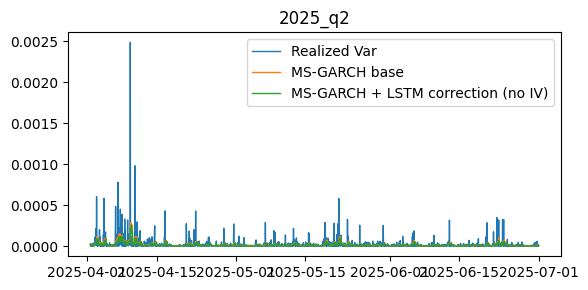

2025_q2
                  RMSE       MAE       NLL     QLIKE      Bias
MS_base       0.000077  0.000024 -3.915482 -9.668842  0.000002
MS_LSTM_noIV  0.000076  0.000021 -3.712476 -9.262830  0.000007


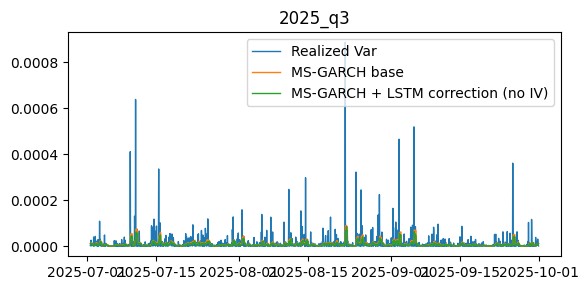

2025_q3
                  RMSE       MAE       NLL     QLIKE      Bias
MS_base       0.000038  0.000013 -4.071302 -9.980481  0.000001
MS_LSTM_noIV  0.000038  0.000012 -3.774415 -9.386706  0.000004


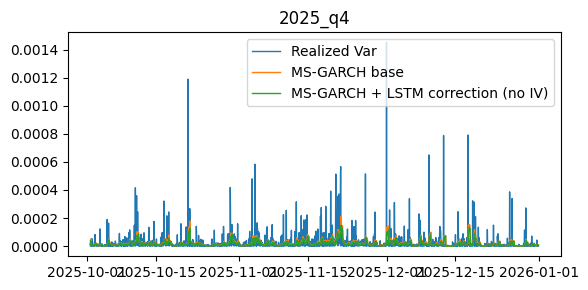

2025_q4
                  RMSE       MAE       NLL     QLIKE      Bias
MS_base       0.000074  0.000029 -3.593937 -9.025751  0.000003
MS_LSTM_noIV  0.000073  0.000026 -3.347768 -8.533412  0.000008


In [24]:
# MS-GARCH base + LSTM correction (NO IV) per quarter
import torch

quarters = [(
            y,
            q,
            Xq_by_year[y][q]
             ) 
            for y in YEARS 
            for q in ["q1", "q2", "q3", "q4"]]

tables_noIV = {}
rv2_noIV_by_year = {}
h_base2_noIV_by_year = {}
h_finalB_by_year = {}

for y, q, Xq in quarters:

    idx_q    = np.asarray(idx_by_year[y][q], int)
    f_roll_q = np.asarray(f_rollB_by_year[y][q], float)

    t_idx  = Xq.index[idx_q]
    df_use = Xq.loc[t_idx, ["rt"]].copy()

    h_base_s = pd.Series(f_roll_q, index=t_idx)

    mask = df_use["rt"].notna() & np.isfinite(h_base_s.values)
    df_use = df_use.loc[mask]
    h_base = h_base_s.loc[mask].to_numpy(float)

    rv = (df_use["rt"].to_numpy(float) ** 2)
    g  = np.log(rv + 1e-12) - np.log(h_base + 1e-12)

    SEQ_LEN = 5
    feats = df_use[["rt"]].to_numpy(np.float32)

    X_seq, y_target = [], []
    for i in range(SEQ_LEN, len(df_use)):
        X_seq.append(feats[i-SEQ_LEN:i])
        y_target.append(g[i])

    X_seq     = torch.tensor(np.stack(X_seq))
    y_target  = torch.tensor(np.array(y_target, np.float32)).view(-1, 1)

    from src.LSTM_lib import LSTMcorrNoIV

    g_hat = np.full(len(y_target), np.nan, dtype=float)

    for t in range(1, len(y_target)):
        lstm_corr = LSTMcorrNoIV(hidden_dim=32, lr=1e-3, epochs=30).fit_xy(X_seq[:t], y_target[:t]) # no look ahead bias
        g_hat[t] = lstm_corr.predict(X_seq[t:t+1])[0]

    h_base2  = h_base[SEQ_LEN:][1:]
    rv2      = rv[SEQ_LEN:][1:]
    x_plot2  = df_use.index[SEQ_LEN:][1:]
    h_finalB = h_base2 * np.exp(g_hat[1:])

    plt.figure(figsize=(6,3))
    plt.plot(x_plot2, rv2,      linewidth=1, label="Realized Var")
    plt.plot(x_plot2, h_base2,  linewidth=1, label="MS-GARCH base")
    plt.plot(x_plot2, h_finalB, linewidth=1, label="MS-GARCH + LSTM correction (no IV)")
    plt.title(f"{y}_{q}"); plt.legend(); plt.tight_layout(); plt.show()

    results = {}
    results["MS_base"]      = metrics(rv2, h_base2)
    results["MS_LSTM_noIV"] = metrics(rv2, h_finalB)

    table = pd.DataFrame(results, index=["RMSE","MAE","NLL","QLIKE","Bias"]).T.round(6)

    if y not in tables_noIV:
        tables_noIV[y] = {}
        rv2_noIV_by_year[y] = {}
        h_base2_noIV_by_year[y] = {}
        h_finalB_by_year[y] = {}

    tables_noIV[y][q] = table
    rv2_noIV_by_year[y][q] = rv2
    h_base2_noIV_by_year[y][q] = h_base2
    h_finalB_by_year[y][q] = h_finalB

    print(f"{y}_{q}")
    print(table)

In [ ]:
# SAVE NO IV
import pickle

pickle.dump(
    {
        "tables_noIV": tables_noIV,
        "rv2_noIV_by_year": rv2_noIV_by_year,
        "h_base2_noIV_by_year": h_base2_noIV_by_year,
        "h_finalB_by_year": h_finalB_by_year,
    },
    open("outputs/ms_garch_noIV_outputs.pkl", "wb")
)

In [17]:
print([i for i in globals() if not i.startswith("__") and  i.startswith("rv")])

['rv2_gatedIV_by_year', 'rv2_noIV_by_year']


# Evaluation

In [22]:
quarters = [(y, q, Xq_by_year[y][q]) for y in YEARS for q in ["q1","q2","q3","q4"]]

tables_all = {}

for y, q, _ in quarters:
    results = {}

    rv2_q      = rv2_gatedIV_by_year[y][q]
    h_base2_q  = h_base2_gatedIV_by_year[y][q]
    h_finalB_q = h_finalB_by_year[y][q]
    h_final_q  = h_final_byQ[y][q]

    results["MS_base"]      = metrics(rv2_q, h_base2_q)
    results["MS_LSTM_noIV"] = metrics(rv2_q, h_finalB_q)
    results["MS_LSTM_wIV"]  = metrics(rv2_q, h_final_q)

    table = pd.DataFrame(results, index=["RMSE","MAE","NLL","QLIKE","Bias"]).T.round(6)

    if y not in tables_all:
        tables_all[y] = {}

    tables_all[y][q] = table

    print(f"{y}_{q}")
    print(table)

2022_q1
                  RMSE       MAE       NLL     QLIKE      Bias
MS_base       0.000156  0.000067 -3.388802 -8.615480 -0.000002
MS_LSTM_noIV  0.000153  0.000058 -3.193961 -8.225799  0.000012
MS_LSTM_wIV   0.000151  0.000062 -3.510812 -8.859502  0.000003
2022_q2
                  RMSE       MAE       NLL     QLIKE      Bias
MS_base       0.000254  0.000097 -3.364607 -8.567091 -0.000024
MS_LSTM_noIV  0.000234  0.000081 -3.193014 -8.223905  0.000001
MS_LSTM_wIV   0.000227  0.000084 -3.492109 -8.822094 -0.000005
2022_q3
                  RMSE       MAE       NLL     QLIKE      Bias
MS_base       0.000154  0.000067 -3.394161 -8.626200 -0.000017
MS_LSTM_noIV  0.000145  0.000057 -3.231651 -8.301180 -0.000001
MS_LSTM_wIV   0.000143  0.000064 -3.521129 -8.880136 -0.000014
2022_q4
                  RMSE       MAE       NLL     QLIKE      Bias
MS_base       0.000154  0.000035 -1.936874 -5.711625 -0.000001
MS_LSTM_noIV  0.000144  0.000030 -0.733673 -3.305223  0.000007
MS_LSTM_wIV   0.000143 

### LSTM correction procedure (what I do)

For each time $t$, define realized variance and the MS-GARCH base variance:
$$RV_t = r_t^2,$$
$$h^{\text{base}}_t = \text{MS-GARCH forecast variance at }t.$$

Define the log-correction target:
$$g_t = \log(RV_t+\varepsilon) - \log(h^{\text{base}}_t+\varepsilon).$$

Build an input sequence of length $L$ (our `SEQ_LEN`) from features $x_t$:
$$S_t = [x_{t-L}, x_{t-L+1}, \dots, x_{t-1}].$$

LSTM mapping:
$$h_t^{\text{LSTM}} = \mathrm{LSTM}(S_t), \qquad \hat g_t = W h_t^{\text{LSTM}} + b.$$

Final variance forecast:
$$\hat h_t = h^{\text{base}}_t \exp(\hat g_t).$$

**Variables:**  
$r_t$ = hourly return; $RV_t$ = realized variance; $h^{\text{base}}_t$ = MS-GARCH base variance;  
$x_t$ = input features (either $[bsIV_t, MFIV_t]$ or $[r_t]$); $L$ = sequence length;  
$\hat g_t$ = predicted log-correction; $\hat h_t$ = corrected variance forecast; $\varepsilon=10^{-12}$.


## The correction parameter. (Can be interpreted as log multiplicative correction factor coming from IV)
If $\hat{g}_t = 0$ → model keeps MS-GARCH.

If $\hat{g}_t > 0$ → model scales variance up.

If $\hat{g}_t < 0$ → model scales variance down.

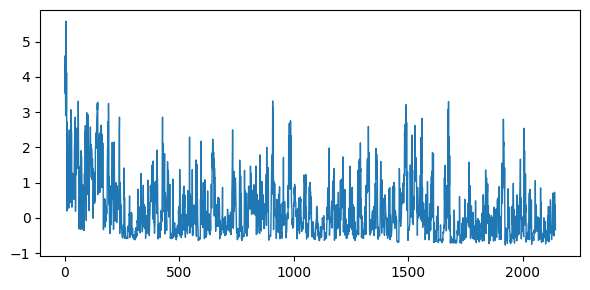

In [90]:
plt.figure(figsize=(6,3))
plt.plot(g_hat_byQ[2023]["q1"], linewidth=1)
plt.tight_layout()
plt.show()

In [91]:
from statsmodels.stats.diagnostic import acorr_ljungbox
print(acorr_ljungbox(g_hat_byQ[2023]["q1"], lags=[10], return_df=True))

        lb_stat  lb_pvalue
10  4805.239277        0.0


In [86]:
from statsmodels.tsa.stattools import adfuller
print(adfuller(g_hat_byQ[2023]["q1"]))  

(np.float64(-6.918857942173157), np.float64(1.1603844977408025e-09), 15, 2128, {'1%': np.float64(-3.433426694407439), '5%': np.float64(-2.8628991628306677), '10%': np.float64(-2.567493552640412)}, np.float64(3447.5736991720596))


In [84]:
from statsmodels.stats.diagnostic import het_arch
print(het_arch(g_hat_byQ[2023]["q1"]))

(np.float64(856.3709501710687), np.float64(1.5552275847192697e-177), 142.30073490083925, 4.494353008124297e-228)


Diagnostic summary (correction term gt): 
- Reject Ljung box. gt is serially dependent.
- Reject unit root. gt is stationary.
- Reject ARCH.  gt is heteroskedastic and has time-varying variance. It tests whether the squared values of gt are serially correlated (they are).

ie. Periods of large corrections are followed by large corrections, and periods of small corrections are followed by small ones.


